In [1]:
import folium

# Pusat peta di tengah area AOI
lat_c = (-7.1927923 + -7.1514786) / 2
lon_c = (112.6193968 + 112.6600158) / 2

m = folium.Map(location=[lat_c, lon_c], zoom_start=12)

# Tandai area polygon AOI Kabupaten Gresik
folium.Rectangle(
    bounds=[[-7.1927923, 112.6193968], [-7.1514786, 112.6600158]],
    color="red",
    fill=True,
    fill_opacity=0.2,
    tooltip="Area Kabupaten Gresik",
).add_to(m)

m

In [2]:
import pandas as pd

# Menampilkan 5 data teratas CSV CH4
df_ch4 = pd.read_csv("./../data/csv/CH4_gresik_timeseries.csv")
df_ch4.head()

,date,CH4
0,2025-08-24,NaN
1,2025-08-25,1867.289429
2,2025-08-26,NaN
3,2025-08-27,NaN
4,2025-08-28,NaN


In [3]:
import pandas as pd

# Menampilkan 5 data teratas CSV CO
df_co = pd.read_csv("./../data/csv/CO_gresik_timeseries.csv")
df_co.head()

,date,CO
0,2025-08-24,0.037918
1,2025-08-25,0.028240
2,2025-08-26,NaN
3,2025-08-27,0.034187
4,2025-08-28,0.027450


In [4]:
import pandas as pd

# Menampilkan 5 data teratas CSV NO2
df_no2 = pd.read_csv("./../data/csv/NO2_gresik_timeseries.csv")
df_no2.head()

,date,NO2
0,2025-08-24,0.000096
1,2025-08-25,0.000046
2,2025-08-26,0.000068
3,2025-08-27,NaN
4,2025-08-28,0.000060


In [5]:
import pandas as pd

# Menampilkan 5 data teratas CSV SO2
df_so2 = pd.read_csv("./../data/csv/SO2_gresik_timeseries.csv")
df_so2.head()

,date,SO2
0,2025-08-24,0.000347
1,2025-08-25,0.000817
2,2025-08-26,-0.000799
3,2025-08-27,-0.000513
4,2025-08-28,0.000327


In [6]:
import pandas as pd
df = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv")
ch4 = df["CH4"]
missingValueCH4 = ch4.isna().sum()
validValueCH4 = ch4.notna().sum()
print(f"Jumlah missing value pada data ch4 : {missingValueCH4}")
print(f"Jumlah data terisi (valid) pada data ch4 : {validValueCH4}")

Jumlah missing value pada data ch4 : 335
Jumlah data terisi (valid) pada data ch4 : 31


In [7]:
df = pd.read_csv("../data/csv/CO_gresik_timeseries.csv")
co = df["CO"]
missingValueCO = co.isna().sum()
validValueCO = co.notna().sum()
print(f"Jumlah missing value pada data co : {missingValueCO}")
print(f"Jumlah data terisi (valid) pada data co : {validValueCO}")

Jumlah missing value pada data co : 157
Jumlah data terisi (valid) pada data co : 209


In [8]:
df = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv")
no2 = df["NO2"]
missingValueNO2 = no2.isna().sum()
validValueNO2 = no2.notna().sum()
print(f"Jumlah missing value pada data no2 : {missingValueNO2}")
print(f"Jumlah data terisi (valid) pada data no2 : {validValueNO2}")

Jumlah missing value pada data no2 : 179
Jumlah data terisi (valid) pada data no2 : 187


In [9]:
df = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv")
so2 = df["SO2"]
missingValueSO2 = so2.isna().sum()
validValueSO2 = so2.notna().sum()
print(f"Jumlah missing value pada data so2 : {missingValueSO2}")
print(f"Jumlah data terisi (valid) pada data so2 : {validValueSO2}")

Jumlah missing value pada data so2 : 144
Jumlah data terisi (valid) pada data so2 : 222


Jumlah outlier pada data ch4 : 2
Jumlah tidak outlier (normal) pada data ch4 : 29


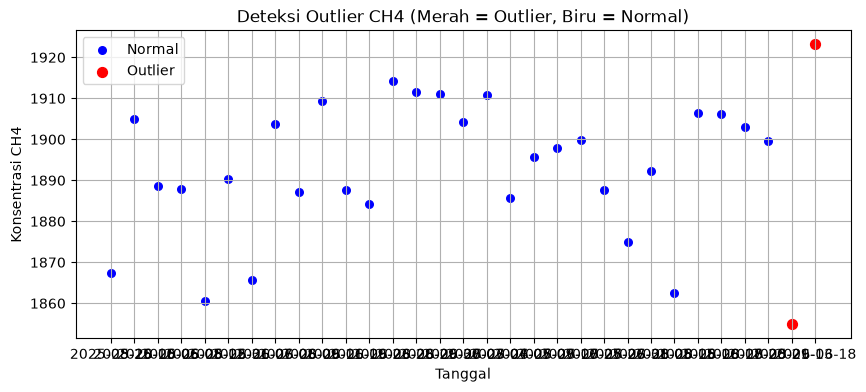

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/CH4_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CH4']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['CH4']])

normal_ch4 = df_clean[df_clean['outlier'] == 1]
outliers_ch4 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data ch4 : {len(outliers_ch4)}")
print(f"Jumlah tidak outlier (normal) pada data ch4 : {len(normal_ch4)}")

# Visualisasi Grafik Outlier CH4
df_clean['date'] = pd.to_datetime(df_clean['date'])

plt.figure(figsize=(10, 4))
plt.scatter(normal_ch4['date'], normal_ch4['CH4'], color='blue', label='Normal', s=30)
plt.scatter(outliers_ch4['date'], outliers_ch4['CH4'], color='red', label='Outlier', s=50)
plt.title('Deteksi Outlier CH4 (Merah = Outlier, Biru = Normal)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi CH4')
plt.legend()
plt.grid(True)
plt.show()

Jumlah outlier pada data co : 11
Jumlah tidak outlier (normal) pada data co : 198


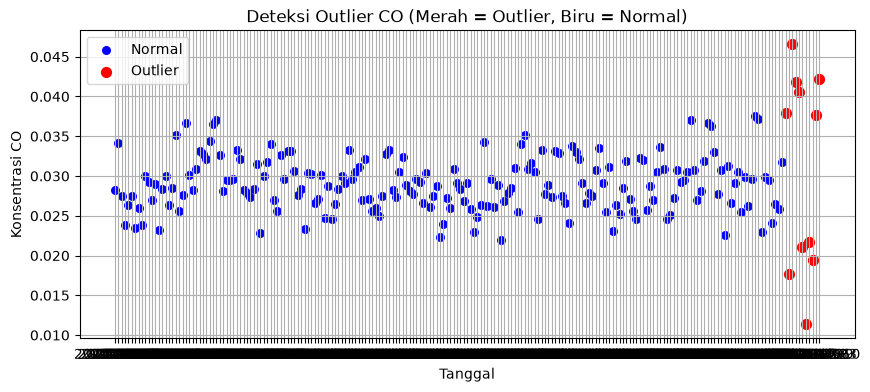

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/CO_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CO']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['CO']])

normal_co = df_clean[df_clean['outlier'] == 1]
outliers_co = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data co : {len(outliers_co)}")
print(f"Jumlah tidak outlier (normal) pada data co : {len(normal_co)}")

# Visualisasi Grafik Outlier CO
df_clean['date'] = pd.to_datetime(df_clean['date'])

plt.figure(figsize=(10, 4))
plt.scatter(normal_co['date'], normal_co['CO'], color='blue', label='Normal', s=30)
plt.scatter(outliers_co['date'], outliers_co['CO'], color='red', label='Outlier', s=50)
plt.title('Deteksi Outlier CO (Merah = Outlier, Biru = Normal)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi CO')
plt.legend()
plt.grid(True)
plt.show()

Jumlah outlier pada data no2 : 10
Jumlah tidak outlier (normal) pada data no2 : 177


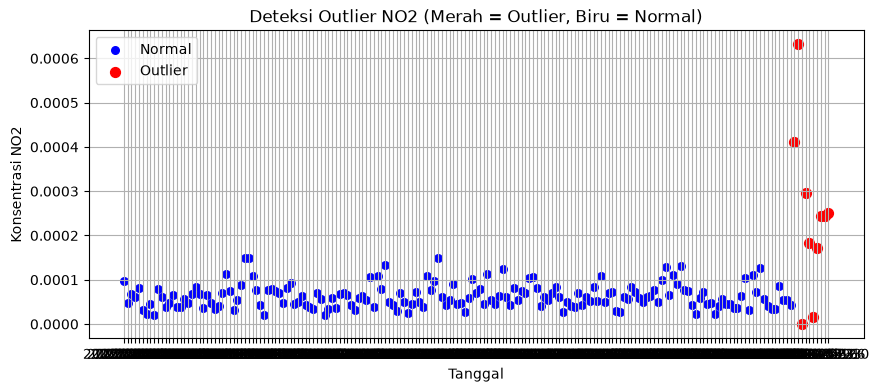

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/NO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['NO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['NO2']])

normal_no2 = df_clean[df_clean['outlier'] == 1]
outliers_no2 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data no2 : {len(outliers_no2)}")
print(f"Jumlah tidak outlier (normal) pada data no2 : {len(normal_no2)}")

# Visualisasi Grafik Outlier NO2
df_clean['date'] = pd.to_datetime(df_clean['date'])

plt.figure(figsize=(10, 4))
plt.scatter(normal_no2['date'], normal_no2['NO2'], color='blue', label='Normal', s=30)
plt.scatter(outliers_no2['date'], outliers_no2['NO2'], color='red', label='Outlier', s=50)
plt.title('Deteksi Outlier NO2 (Merah = Outlier, Biru = Normal)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi NO2')
plt.legend()
plt.grid(True)
plt.show()

Jumlah outlier pada data so2 : 12
Jumlah tidak outlier (normal) pada data so2 : 210


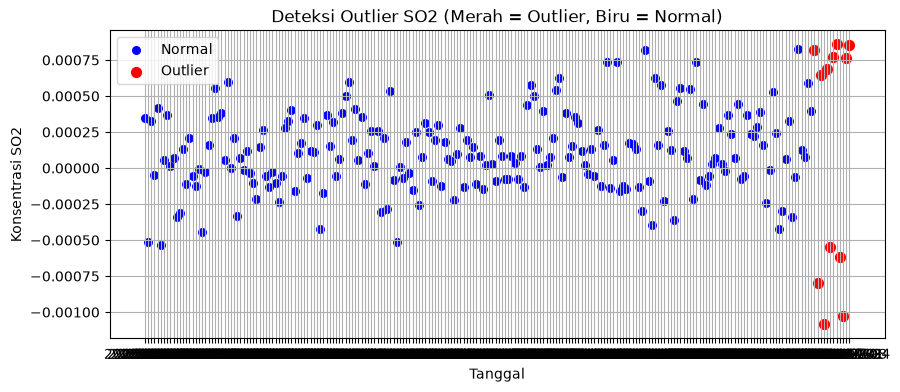

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../data/csv/SO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['SO2']).copy()

model = IsolationForest(contamination=0.05, random_state=42)
df_clean['outlier'] = model.fit_predict(df_clean[['SO2']])

normal_so2 = df_clean[df_clean['outlier'] == 1]
outliers_so2 = df_clean[df_clean['outlier'] == -1]

print(f"Jumlah outlier pada data so2 : {len(outliers_so2)}")
print(f"Jumlah tidak outlier (normal) pada data so2 : {len(normal_so2)}")

# Visualisasi Grafik Outlier SO2
df_clean['date'] = pd.to_datetime(df_clean['date'])

plt.figure(figsize=(10, 4))
plt.scatter(normal_so2['date'], normal_so2['SO2'], color='blue', label='Normal', s=30)
plt.scatter(outliers_so2['date'], outliers_so2['SO2'], color='red', label='Outlier', s=50)
plt.title('Deteksi Outlier SO2 (Merah = Outlier, Biru = Normal)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi SO2')
plt.legend()
plt.grid(True)
plt.show()